In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
from submit_test import ModelTester

/dss/dsshome1/00/di54xat/cloudsen12/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

from src.misc import select_patches_from_dataset
from src.dataset import TestS2TIFDataSet, TestS2TIFDataSet512
from src.model import UNet
from src.training.lwf_unet_aspp_trainer import UNet as ASPPUNet
from pathlib import Path


# Testing models
Idea is to train on no-label/scribble and test on high from cloudsen12

In [25]:

def define_tester(
    user: str,
    repo: str = "cloudsen12",
    seed:int = 42,
    csv_name: str = "cloudsen12_initial_high_test.csv",
    epochs: int = 16,
    patch_size: int = 256,
    batch_size: int = 12,
    num_workers: int = 16,
    prefetch_factor: int = 8,
    experiment_id: str = "cloudsen12_aspp_scribble_multitypecloud_256_1_000_cthr03_noweights",
    partition: str = "hpda2_compute_gpu",
    time: str = "03:00:00",
    gpus_per_node: int = 1,
    mem_gb: int = 256,
    account: str = "pn39sa-c",
    clusters: str = "hpda2",
    mail_user: str | None = None,
    exclude_nodes: str | None = None,
):

    root_hpc = Path("/dss/dsstbyfs02/pn49ci/pn49ci-dss-0026")
    user_path = root_hpc / user
    log_dir = user_path / "experiments/LWF-DLR/slurm_logs/test"
    log_dir.mkdir(parents=True, exist_ok=True)

    cpus_per_task = 2 + num_workers

    experiment_group: str = "LWF-DLR"

    data_path = user_path / repo / "data"

    # Load dataset
    file_names = select_patches_from_dataset(
        data_path / csv_name, 
        data_path,
        type_folder="", # not supported here
    )

    use_aspp_trainer = True
    if use_aspp_trainer:
        model = ASPPUNet()
    else:
        model = UNet()


    if patch_size == 512:
        dataset = TestS2TIFDataSet512(
            file_names,
            seed
        )
    else: #default
        dataset = TestS2TIFDataSet(
            file_names,
            seed
        )

    model_name = "best_model.pth"
    tester = ModelTester(
        model,
        dataset,
        batch_size,
        num_workers,
        "cuda",
        user,
        repo,
        experiment_group, 
        experiment_id,
        model_name,
    )


    return tester, dataset

In [26]:
tester, dataset = define_tester("di54xat") # not passing to slurm

/dss/dsshome1/00/di54xat/cloudsen12/.venv/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
print(tester())

Test:   0%|          | 0/834 [00:00<?, ?it/s]/dss/dsshome1/00/di54xat/cloudsen12/.venv/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Test:  12%|█▏        | 96/834 [00:37<03:29,  3.52it/s] 

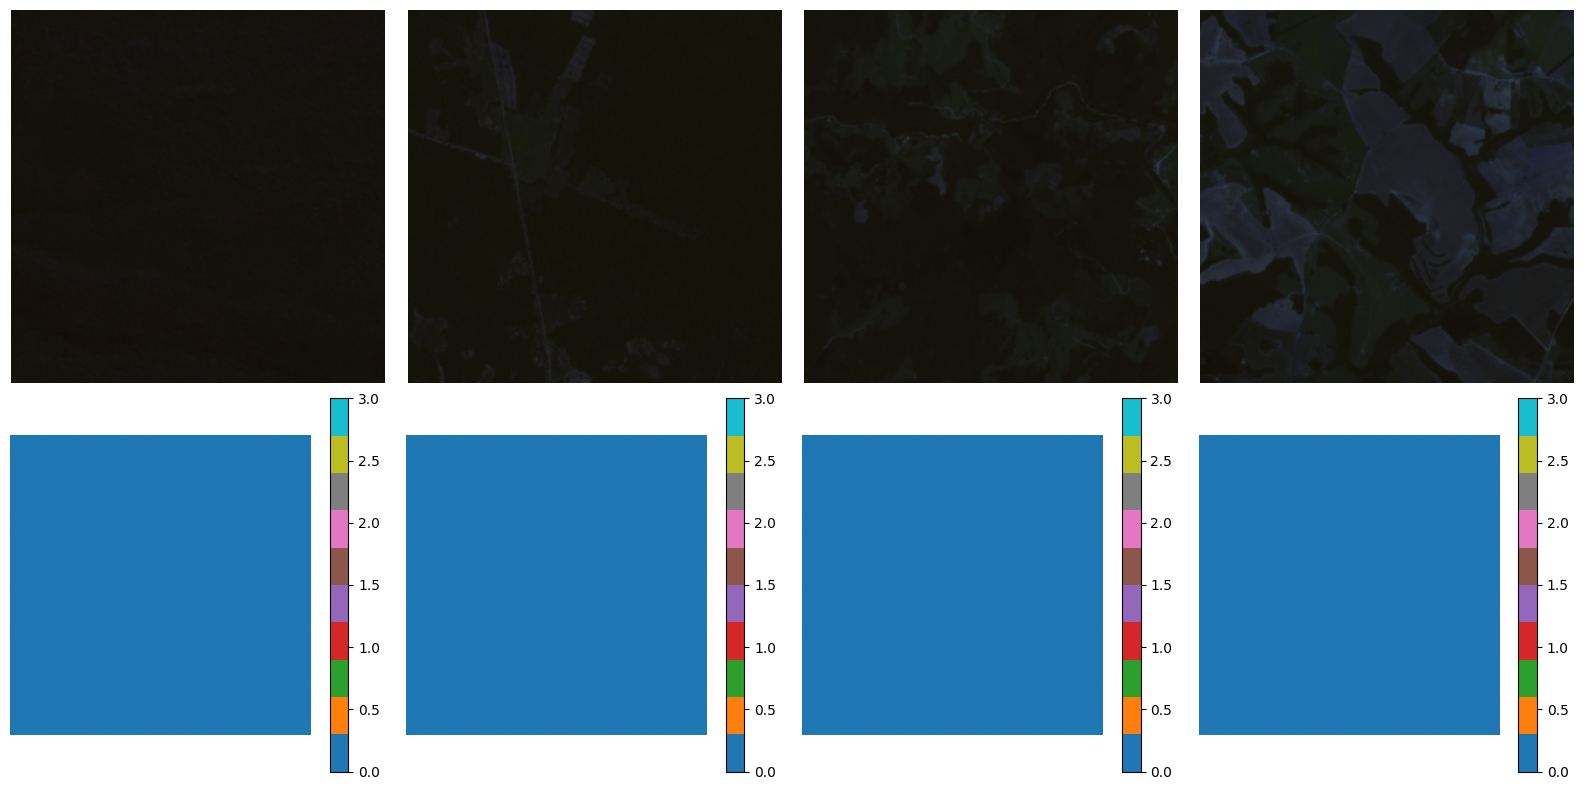

In [ ]:
# check what the loader loads
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))


for i in range(4):
    rand_id = i # int(random.random() * len(train_dataset))
    sample_x, sample_y = dataset[rand_id]

    # Plot input
    axes[0, i].imshow(sample_x[:3].permute(1,2,0).numpy())
    axes[0, i].axis("off")

    # Plot target
    im = axes[1, i].imshow(sample_y.numpy(), cmap="tab10", vmin=0, vmax=3)
    
    fig.colorbar(im, ax=axes[1, i])

    axes[1, i].axis("off")

#plt.colorbar()
plt.tight_layout()
plt.show()